# 05 Detecting Deviations from Expected Cycling Counts

This notebook identifies deviations from expected cycling traffic during the prediction period from May 2025 to April 2026.

The expected counts were computed in the previous notebook using the final negative binomial model. In this notebook, observed counts are compared with expected counts. A 2-hour interval is classified as a deviation only when the difference is both large in absolute terms (larger than 25) and large relative to the expected count (larger than 0.75).

### Packages and path

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
import nbformat

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.express as plotly



project_folder = Path("..")

processed_folder = project_folder / "data" / "processed"
diagnostics_folder = project_folder / "data" / "diagnostics"

### Loading model development data

In [2]:
model_development_data = pd.read_csv(
    processed_folder / "model_development_data.csv"
)

model_development_data["date"] = pd.to_datetime(
    model_development_data["date"],
    errors="coerce"
)

model_development_data.info()
model_development_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 3361867 entries, 0 to 3361866
Data columns (total 28 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   site_id                       int64         
 1   direction                     str           
 2   year                          int64         
 3   date                          datetime64[us]
 4   month                         int64         
 5   weekday                       str           
 6   hour_bin                      int64         
 7   count                         float64       
 8   observed_intervals            int64         
 9   total_intervals               int64         
 10  missing_intervals             int64         
 11  missing_share                 float64       
 12  expected_intervals_for_row    int64         
 13  count_rescaled                int64         
 14  rescaled                      int64         
 15  longitude                     float64      

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,...,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,fuel_price_petrol_95_rounded
0,1,IN,2022,2022-05-01,5,Sunday,0,13.0,8,8,...,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,1.8
1,1,IN,2022,2022-05-01,5,Sunday,2,2.0,8,8,...,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,1.8
2,1,IN,2022,2022-05-01,5,Sunday,4,1.0,8,8,...,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,1.8
3,1,IN,2022,2022-05-01,5,Sunday,6,6.0,8,8,...,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,1.8
4,1,IN,2022,2022-05-01,5,Sunday,8,26.0,8,8,...,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153,1.8


### Loading expected count data

In [3]:
expected_counts = pd.read_csv(
    processed_folder / "expected_counts.csv"
)

expected_counts["date"] = pd.to_datetime(
    expected_counts["date"],
    errors="coerce"
)

expected_counts.info()
expected_counts.head()

<class 'pandas.DataFrame'>
RangeIndex: 1177575 entries, 0 to 1177574
Data columns (total 46 columns):
 #   Column                        Non-Null Count    Dtype         
---  ------                        --------------    -----         
 0   site_id                       1177575 non-null  int64         
 1   direction                     1177575 non-null  str           
 2   year                          1177575 non-null  int64         
 3   date                          1177575 non-null  datetime64[us]
 4   month                         1177575 non-null  int64         
 5   weekday                       1177575 non-null  str           
 6   hour_bin                      1177575 non-null  int64         
 7   count                         1177575 non-null  float64       
 8   observed_intervals            1177575 non-null  int64         
 9   total_intervals               1177575 non-null  int64         
 10  missing_intervals             1177575 non-null  int64         
 11  missing_s

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,...,precipitation_category,is_strike,is_outdoor_music,outdoor_music_event_type,is_indoor_music,indoor_music_event_type,is_sport_event,sport_event_type,fuel_price_petrol_95_rounded,expected_count
0,1,IN,2025,2025-05-01,5,Thursday,0,1.0,8,8,...,dry,0,0,No event,0,No event,0,No event,1.5,1.570605
1,1,IN,2025,2025-05-01,5,Thursday,2,1.0,8,8,...,dry,0,0,No event,0,No event,0,No event,1.5,0.834287
2,1,IN,2025,2025-05-01,5,Thursday,4,3.0,8,8,...,dry,0,0,No event,0,No event,0,No event,1.5,6.207436
3,1,IN,2025,2025-05-01,5,Thursday,6,3.0,8,8,...,dry,0,0,No event,0,No event,0,No event,1.5,36.715265
4,1,IN,2025,2025-05-01,5,Thursday,8,43.0,8,8,...,dry,0,0,No event,0,No event,0,No event,1.5,41.707795


Basic checks

In [4]:
print("Rows:", expected_counts.shape[0])
print("Columns:", expected_counts.shape[1])

print("Date range:")
print(expected_counts["date"].min(), "to", expected_counts["date"].max())

print("Missing observed counts:", expected_counts["count_rescaled"].isna().sum())
print("Missing expected counts:", expected_counts["expected_count"].isna().sum())

print("Minimum expected count:", expected_counts["expected_count"].min())
print("Maximum expected count:", expected_counts["expected_count"].max())

Rows: 1177575
Columns: 46
Date range:
2025-05-01 00:00:00 to 2026-04-30 00:00:00
Missing observed counts: 0
Missing expected counts: 0
Minimum expected count: 0.0268975028755632
Maximum expected count: 996.2876399297444


In [5]:
event_factors = [
    "is_strike",
    "is_outdoor_music",
    "is_indoor_music",
    "is_sport_event",
]

for col in event_factors:
    print("\n", col)
    print(expected_counts[col].value_counts(dropna=False))
    print("Unique values:", expected_counts[col].unique()[:10])
    print("Dtype:", expected_counts[col].dtype)


 is_strike
is_strike
0    1129175
1      48400
Name: count, dtype: int64
Unique values: [0 1]
Dtype: int64

 is_outdoor_music
is_outdoor_music
0    1175439
1       2136
Name: count, dtype: int64
Unique values: [0 1]
Dtype: int64

 is_indoor_music
is_indoor_music
0    1177287
1        288
Name: count, dtype: int64
Unique values: [0 1]
Dtype: int64

 is_sport_event
is_sport_event
0    1175971
1       1604
Name: count, dtype: int64
Unique values: [0 1]
Dtype: int64


## Defining Deviations

### Defining reference counts

The expected count must be based on at least 10 reference observations from the model-development period. Reference observations are defined as observations with the same site, direction, month, weekday, and 2-hour time bin. We therefore compute the number of reference observations here.

In [6]:
reference_variables = [
    "site_id",
    "direction",
    "month",
    "weekday",
    "hour_bin",
]

reference_counts = (
    model_development_data
    .groupby(reference_variables)
    .size()
    .reset_index(name="reference_n")
)

deviation_data = expected_counts.merge(
    reference_counts,
    on=reference_variables,
    how="left"
)

print("Missing reference_n:", deviation_data["reference_n"].isna().sum())

deviation_data["reference_n"] = (
    deviation_data["reference_n"]
    .fillna(0)
    .astype(int)
)

Missing reference_n: 0


In [7]:
print("Share with reference_n >= 10:")
print((deviation_data["reference_n"] >= 10).mean())

deviation_data["reference_n"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50]
)

Share with reference_n >= 10:
0.8057210793367726


count    1.177575e+06
mean     1.199000e+01
std      1.967225e+00
min      4.000000e+00
1%       8.000000e+00
5%       8.000000e+00
10%      9.000000e+00
25%      1.200000e+01
50%      1.300000e+01
max      1.400000e+01
Name: reference_n, dtype: float64

### Computing differences between observed and expected counts

In [8]:
deviation_data["difference"] = (
    deviation_data["count_rescaled"] - deviation_data["expected_count"]
)

deviation_data["relative_difference"] = (
    deviation_data["difference"] / deviation_data["expected_count"]
)

### Defining deviations

A 2-hour observation is classified as a deviation only when it satisfies all three conditions:

1) The expected count must be based on at least 10 reference observations from the model-development period. Reference observations are defined as observations with the same site, direction, month, weekday, and 2-hour time bin.

2) The observed count must differ from the expected count by at least 25 cyclists. This absolute threshold ensures that very small numerical differences are not interpreted as meaningful deviations.

3) The difference must also be at least 75% of the expected count. This relative threshold ensures that the deviation is large compared with the normal level of cycling traffic for that specific site and time period.

In [9]:
MIN_REFERENCE_N = 10
ABSOLUTE_DIFFERENCE_THRESHOLD = 25
RELATIVE_DIFFERENCE_THRESHOLD = 0.75

deviation_data["is_deviation"] = (
    (deviation_data["reference_n"] >= MIN_REFERENCE_N) &
    (deviation_data["difference"].abs() >= ABSOLUTE_DIFFERENCE_THRESHOLD) &
    (deviation_data["relative_difference"].abs() >= RELATIVE_DIFFERENCE_THRESHOLD)
).astype(int)

In [10]:
deviation_data["deviation_direction"] = "No deviation"

deviation_data.loc[
    (deviation_data["is_deviation"] == 1) &
    (deviation_data["difference"] > 0),
    "deviation_direction"
] = "Higher than expected"

deviation_data.loc[
    (deviation_data["is_deviation"] == 1) &
    (deviation_data["difference"] < 0),
    "deviation_direction"
] = "Lower than expected"

In [11]:
deviation_data.head(10)

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,...,indoor_music_event_type,is_sport_event,sport_event_type,fuel_price_petrol_95_rounded,expected_count,reference_n,difference,relative_difference,is_deviation,deviation_direction
0,1,IN,2025,2025-05-01,5,Thursday,0,1.0,8,8,...,No event,0,No event,1.5,1.570605,13,-0.570605,-0.363303,0,No deviation
1,1,IN,2025,2025-05-01,5,Thursday,2,1.0,8,8,...,No event,0,No event,1.5,0.834287,13,0.165713,0.198629,0,No deviation
2,1,IN,2025,2025-05-01,5,Thursday,4,3.0,8,8,...,No event,0,No event,1.5,6.207436,13,-3.207436,-0.516709,0,No deviation
3,1,IN,2025,2025-05-01,5,Thursday,6,3.0,8,8,...,No event,0,No event,1.5,36.715265,13,-33.715265,-0.918290,1,Lower than expected
4,1,IN,2025,2025-05-01,5,Thursday,8,43.0,8,8,...,No event,0,No event,1.5,41.707795,13,1.292205,0.030982,0,No deviation
5,1,IN,2025,2025-05-01,5,Thursday,10,28.0,8,8,...,No event,0,No event,1.5,27.603782,13,0.396218,0.014354,0,No deviation
6,1,IN,2025,2025-05-01,5,Thursday,12,19.0,8,8,...,No event,0,No event,1.5,36.223882,13,-17.223882,-0.475484,0,No deviation
7,1,IN,2025,2025-05-01,5,Thursday,14,45.0,8,8,...,No event,0,No event,1.5,48.032402,13,-3.032402,-0.063132,0,No deviation
8,1,IN,2025,2025-05-01,5,Thursday,16,26.0,8,8,...,No event,0,No event,1.5,60.624957,13,-34.624957,-0.571134,0,No deviation
9,1,IN,2025,2025-05-01,5,Thursday,18,19.0,8,8,...,No event,0,No event,1.5,26.469498,13,-7.469498,-0.282193,0,No deviation


# Analyzing Deviations: EDA

### Overall summary

In [12]:
overall_summary = pd.DataFrame({
    "total_observations": [deviation_data.shape[0]],
    "total_deviations": [deviation_data["is_deviation"].sum()],
    "share_deviations": [deviation_data["is_deviation"].mean()],
    "higher_deviation_count": [
        (deviation_data["deviation_direction"] == "Higher than expected").sum()
    ],
    "lower_deviation_count": [
        (deviation_data["deviation_direction"] == "Lower than expected").sum()
    ],
})

overall_summary

,total_observations,total_deviations,share_deviations,higher_deviation_count,lower_deviation_count
0,1177575,129793,0.110221,76613,53180


In [13]:
deviation_rows = deviation_data["is_deviation"] == 1

### Size of the deviations

In [14]:
deviation_data.loc[
    deviation_rows,
    "difference"
].describe()

count    129793.000000
mean         23.122037
std          77.008641
min        -374.538511
25%         -34.760885
50%          30.485943
75%          57.817373
max        1889.474262
Name: difference, dtype: float64

In [15]:
deviation_data.loc[deviation_rows].groupby("deviation_direction")[
    "difference"
].describe()

,count,mean,std,min,25%,50%,75%,max
deviation_direction,,,,,,,,
Higher than expected,76613.0,71.366296,62.880889,25.001955,34.818373,50.578283,83.075470,1889.474262
Lower than expected,53180.0,-46.380360,24.367882,-374.538511,-53.402717,-38.753790,-30.597049,-25.001969


Approximatelly 11% of the analyzed observations are classified as deviations with the selected threshold. Higher-than-expected deviations are more frequent than lower-than-expected deviations.

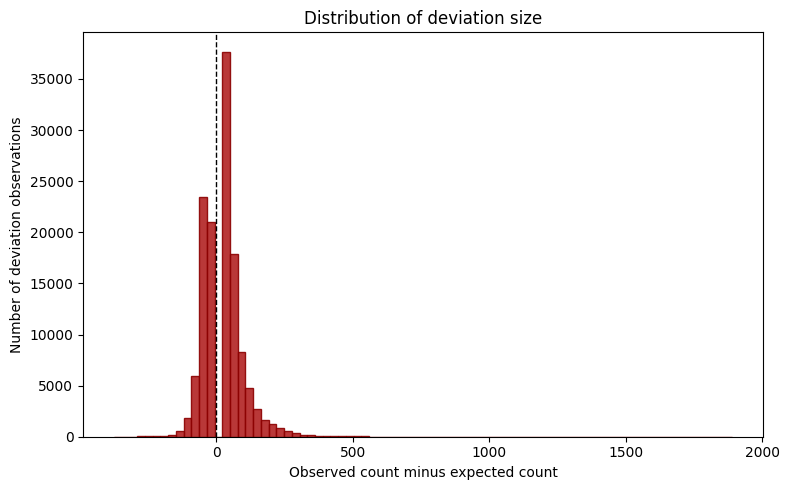

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(
    deviation_data.loc[deviation_rows, "difference"],
    bins=80,
    color="firebrick",
    edgecolor="darkred",
    alpha=0.90
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Observed count minus expected count")
plt.ylabel("Number of deviation observations")
plt.title("Distribution of deviation size")

plt.tight_layout()
plt.show()

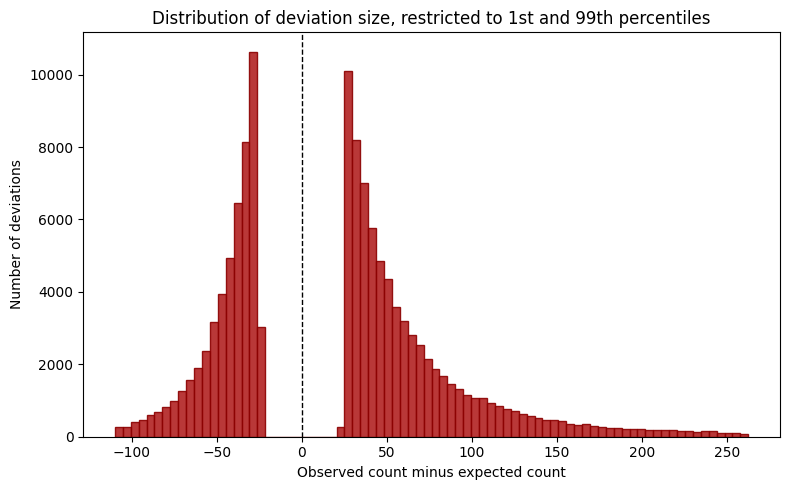

In [17]:

deviation_differences = deviation_data.loc[
    deviation_rows,
    "difference"
]

lower_limit = deviation_differences.quantile(0.01)
upper_limit = deviation_differences.quantile(0.99)

deviation_differences_capped = deviation_differences[
    (deviation_differences >= lower_limit) &
    (deviation_differences <= upper_limit)
]

plt.figure(figsize=(8, 5))

plt.hist(
    deviation_differences_capped,
    bins=80,
    color="firebrick",
    edgecolor="darkred",
    alpha=0.90
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Observed count minus expected count")
plt.ylabel("Number of deviations")
plt.title("Distribution of deviation size, restricted to 1st and 99th percentiles")

plt.tight_layout()
plt.show()

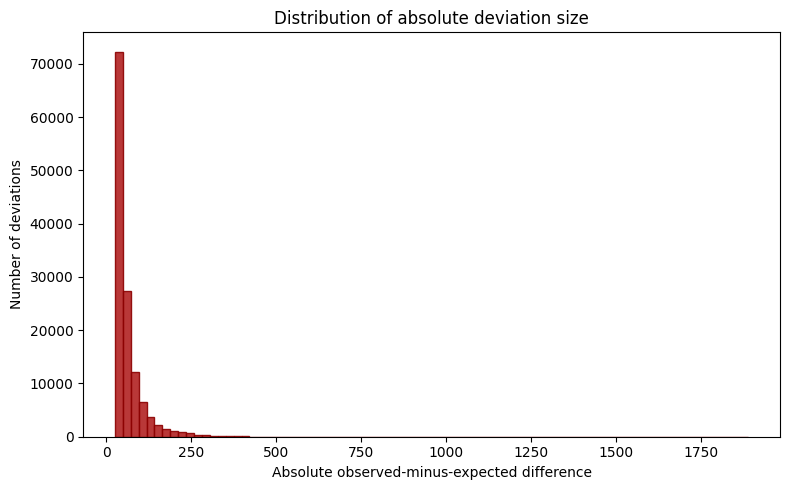

In [18]:
deviation_size_abs = deviation_data.loc[
    deviation_rows,
    "difference"
].abs()

plt.figure(figsize=(8, 5))

plt.hist(
    deviation_size_abs,
    bins=80,
    color="firebrick",
    edgecolor="darkred",
    alpha=0.90
)

plt.xlabel("Absolute observed-minus-expected difference")
plt.ylabel("Number of deviations")
plt.title("Distribution of absolute deviation size")

plt.tight_layout()
plt.show()

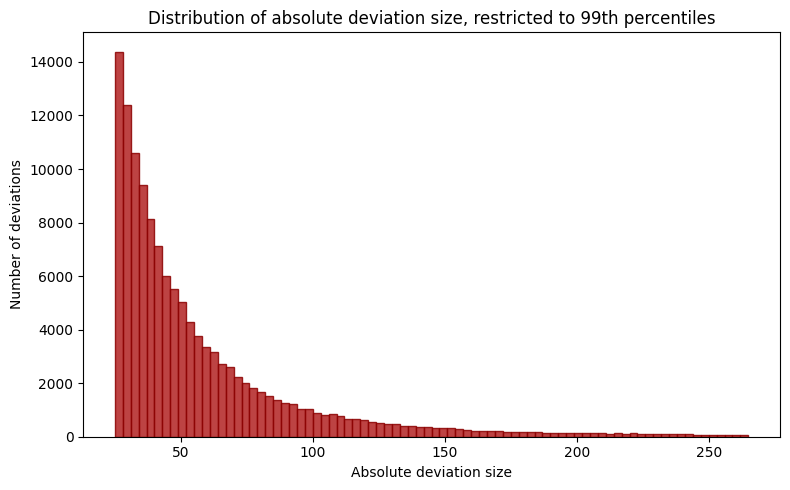

In [19]:
upper_limit = deviation_size_abs.quantile(0.99)

plt.figure(figsize=(8, 5))

plt.hist(
    deviation_size_abs[deviation_size_abs <= upper_limit],
    bins=80,
    color="firebrick",
    edgecolor="darkred",
    alpha=0.85
)

plt.xlabel("Absolute deviation size")
plt.ylabel("Number of deviations")
plt.title("Distribution of absolute deviation size, restricted to 99th percentiles")

plt.tight_layout()
plt.show()

**Dashboard idea**
Later in dashboard we will have one graph where it will be possible to choose:
- Time period: month, quater, or full period
- Deviation measure: signed differences or absolute
- Range: full range or restricted to 1st-99th percentile


### Largest deviations

In [20]:
deviation_data.loc[
    deviation_rows
].sort_values(
    "difference",
    ascending=False
)[
    [
        "site_id",
        "site_name",
        "municipality",
        "district",
        "date",
        "weekday",
        "hour_bin",
        "direction",
        "count_rescaled",
        "expected_count",
        "difference",
        "relative_difference",
        "deviation_direction",
        "precipitation_category",
        "is_strike",
        "is_outdoor_music",
        "is_indoor_music",
        "is_sport_event",
    ]
].head(20)

,site_id,site_name,municipality,district,date,weekday,hour_bin,direction,count_rescaled,expected_count,difference,relative_difference,deviation_direction,precipitation_category,is_strike,is_outdoor_music,is_indoor_music,is_sport_event
1150387,138,Hasselt-Kempische brug,Hasselt,AWV720,2025-08-14,Thursday,18,OUT,2028,138.525738,1889.474262,13.639879,Higher than expected,dry,0,0,0,0
896249,107,leuven totem,Leuven,AWV213,2026-04-19,Sunday,14,IN,1993,321.916248,1671.083752,5.191051,Higher than expected,light_precipitation,0,0,0,0
585996,69,Leuven teller 1,Leuven,AWV213,2026-04-19,Sunday,16,IN,1695,139.545610,1555.454390,11.146566,Higher than expected,dry,0,0,0,0
1150388,138,Hasselt-Kempische brug,Hasselt,AWV720,2025-08-14,Thursday,20,OUT,1615,70.777400,1544.222600,21.818018,Higher than expected,dry,0,0,0,0
900629,107,leuven totem,Leuven,AWV213,2026-04-19,Sunday,16,OUT,1663,204.700924,1458.299076,7.124047,Higher than expected,light_precipitation,0,0,0,0
78328,10,Aalst 2,Aalst,AWV415,2025-05-18,Sunday,8,IN,1472,16.029526,1455.970474,90.830537,Higher than expected,dry,0,0,0,0
157150,19,Aalst 1,Aalst,AWV415,2025-05-18,Sunday,8,IN,1478,29.853200,1448.146800,48.508930,Higher than expected,dry,0,0,0,0
715772,84,Roeselare totem,Izegem,GemeenteIzegem,2025-08-15,Friday,12,OUT,1476,36.578405,1439.421595,39.351677,Higher than expected,dry,0,0,0,0
539528,64,Nieuwpoort teller 1,Nieuwpoort,AWV315,2025-08-15,Friday,10,IN,1451,129.527545,1321.472455,10.202250,Higher than expected,dry,0,0,0,0
596600,70,Kampenhout teller 1,Kampenhout,AWV212,2025-09-20,Saturday,12,OUT,1292,30.885087,1261.114913,40.832487,Higher than expected,light_precipitation,0,0,0,0


In [21]:
deviation_data.loc[
    deviation_rows
].sort_values(
    "difference",
    ascending=True
)[
    [
        "site_id",
        "site_name",
        "municipality",
        "district",
        "date",
        "weekday",
        "hour_bin",
        "direction",
        "count_rescaled",
        "expected_count",
        "difference",
        "relative_difference",
        "deviation_direction",
        "precipitation_category",
        "is_strike",
        "is_outdoor_music",
        "is_indoor_music",
        "is_sport_event",
    ]
].head(20)

,site_id,site_name,municipality,district,date,weekday,hour_bin,direction,count_rescaled,expected_count,difference,relative_difference,deviation_direction,precipitation_category,is_strike,is_outdoor_music,is_indoor_music,is_sport_event
893282,107,leuven totem,Leuven,AWV213,2025-08-15,Friday,6,IN,63,437.538511,-374.538511,-0.856013,Lower than expected,dry,0,0,0,0
892982,107,leuven totem,Leuven,AWV213,2025-07-21,Monday,6,IN,36,405.931230,-369.931230,-0.911315,Lower than expected,dry,0,0,0,0
1146175,138,Hasselt-Kempische brug,Hasselt,AWV720,2025-08-28,Thursday,16,IN,68,406.448308,-338.448308,-0.832697,Lower than expected,light_precipitation,0,0,0,0
583033,69,Leuven teller 1,Leuven,AWV213,2025-08-15,Friday,16,IN,64,394.477485,-330.477485,-0.837760,Lower than expected,dry,0,0,0,0
582923,69,Leuven teller 1,Leuven,AWV213,2025-08-06,Wednesday,12,IN,86,409.789971,-323.789971,-0.790136,Lower than expected,dry,0,0,0,0
1146091,138,Hasselt-Kempische brug,Hasselt,AWV720,2025-08-21,Thursday,16,IN,83,406.448308,-323.448308,-0.795792,Lower than expected,dry,0,0,0,0
1145923,138,Hasselt-Kempische brug,Hasselt,AWV720,2025-08-07,Thursday,16,IN,88,406.448308,-318.448308,-0.783490,Lower than expected,dry,0,0,0,0
582864,69,Leuven teller 1,Leuven,AWV213,2025-08-01,Friday,14,IN,82,400.382697,-318.382697,-0.795196,Lower than expected,light_precipitation,0,0,0,0
583091,69,Leuven teller 1,Leuven,AWV213,2025-08-20,Wednesday,12,IN,99,409.789971,-310.789971,-0.758413,Lower than expected,dry,0,0,0,0
897661,107,leuven totem,Leuven,AWV213,2025-08-15,Friday,6,OUT,33,340.977782,-307.977782,-0.903220,Lower than expected,dry,0,0,0,0


## Deviations over time

The baseline deviation share is the overall share of observations classified as deviations.

Group-specific deviation shares are compared with this value to identify months, weekdays, or times of day where deviations are more or less common than usual.

### Summary function

In [22]:
def summarize_deviations(data, group_variable):

    baseline_share = data["is_deviation"].mean()

    summary = (
        data
        .groupby(group_variable)
        .agg(
            observations=("is_deviation", "size"),
            deviations=("is_deviation", "sum")
        )
        .reset_index()
    )

    summary["deviation_share"] = (
        summary["deviations"] / summary["observations"]
    )

    summary["baseline_deviation_share"] = baseline_share

    return summary

### Deviations across months, weekdays, hours

In [23]:
monthly_deviation_summary = summarize_deviations(
    deviation_data,
    "month"
)

monthly_deviation_summary

,month,observations,deviations,deviation_share,baseline_deviation_share
0,1,99968,8079,0.080816,0.110221
1,2,89576,8346,0.093172,0.110221
2,3,100114,14639,0.146223,0.110221
3,4,97084,15724,0.161963,0.110221
4,5,100586,7396,0.073529,0.110221
5,6,96288,8549,0.088786,0.110221
6,7,99502,11094,0.111495,0.110221
7,8,99688,12404,0.124428,0.110221
8,9,97917,12281,0.125423,0.110221
9,10,100510,12001,0.119401,0.110221


In [24]:
weekday_deviation_summary = summarize_deviations(
    deviation_data,
    "weekday"
)

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_deviation_summary = (
    weekday_deviation_summary
    .set_index("weekday")
    .reindex(weekday_order)
    .reset_index()
)

weekday_deviation_summary

,weekday,observations,deviations,deviation_share,baseline_deviation_share
0,Monday,167848,19990,0.119096,0.110221
1,Tuesday,167763,21408,0.127609,0.110221
2,Wednesday,167741,23706,0.141325,0.110221
3,Thursday,171006,21932,0.128253,0.110221
4,Friday,167805,19534,0.116409,0.110221
5,Saturday,167821,11653,0.069437,0.110221
6,Sunday,167591,11570,0.069037,0.110221


In [25]:
hour_deviation_summary = summarize_deviations(
    deviation_data,
    "hour_bin"
)

hour_deviation_summary

,hour_bin,observations,deviations,deviation_share,baseline_deviation_share
0,0,98150,411,0.004187,0.110221
1,2,97876,181,0.001849,0.110221
2,4,98110,1011,0.010305,0.110221
3,6,98156,16362,0.166694,0.110221
4,8,98153,17803,0.181380,0.110221
5,10,98160,13715,0.139721,0.110221
6,12,98163,17618,0.179477,0.110221
7,14,98164,20933,0.213245,0.110221
8,16,98159,24068,0.245194,0.110221
9,18,98162,11759,0.119792,0.110221


### Summary function with direction of deviations taken into account

In [26]:
def summarize_directional_deviations(data, group_variable):
    
    baseline_deviation_share = data["is_deviation"].mean()

    baseline_higher_share = (
        data["deviation_direction"] == "Higher than expected"
    ).mean()

    baseline_lower_share = (
        data["deviation_direction"] == "Lower than expected"
    ).mean()

    summary = (
        data
        .groupby(group_variable)
        .agg(
            observations=("is_deviation", "size"),
            deviations=("is_deviation", "sum"),
            higher_deviations=(
                "deviation_direction",
                lambda x: (x == "Higher than expected").sum()
            ),
            lower_deviations=(
                "deviation_direction",
                lambda x: (x == "Lower than expected").sum()
            )
        )
        .reset_index()
    )

    summary["deviation_share"] = (
        summary["deviations"] / summary["observations"]
    )

    summary["higher_deviation_share"] = (
        summary["higher_deviations"] / summary["observations"]
    )

    summary["lower_deviation_share"] = (
        summary["lower_deviations"] / summary["observations"]
    )

    summary["baseline_deviation_share"] = baseline_deviation_share
    summary["baseline_higher_deviation_share"] = baseline_higher_share
    summary["baseline_lower_deviation_share"] = baseline_lower_share

    return summary

### Deviations across months, weekdays, hours with direction of deviations taken into account

In [27]:
monthly_directional_summary = summarize_directional_deviations(
    deviation_data,
    "month"
)

monthly_directional_summary

,month,observations,deviations,higher_deviations,lower_deviations,deviation_share,higher_deviation_share,lower_deviation_share,baseline_deviation_share,baseline_higher_deviation_share,baseline_lower_deviation_share
0,1,99968,8079,5701,2378,0.080816,0.057028,0.023788,0.110221,0.06506,0.045161
1,2,89576,8346,5206,3140,0.093172,0.058118,0.035054,0.110221,0.06506,0.045161
2,3,100114,14639,9153,5486,0.146223,0.091426,0.054798,0.110221,0.06506,0.045161
3,4,97084,15724,10986,4738,0.161963,0.113160,0.048803,0.110221,0.06506,0.045161
4,5,100586,7396,4215,3181,0.073529,0.041904,0.031625,0.110221,0.06506,0.045161
5,6,96288,8549,4224,4325,0.088786,0.043868,0.044917,0.110221,0.06506,0.045161
6,7,99502,11094,4949,6145,0.111495,0.049738,0.061758,0.110221,0.06506,0.045161
7,8,99688,12404,5713,6691,0.124428,0.057309,0.067119,0.110221,0.06506,0.045161
8,9,97917,12281,6149,6132,0.125423,0.062798,0.062624,0.110221,0.06506,0.045161
9,10,100510,12001,6237,5764,0.119401,0.062054,0.057348,0.110221,0.06506,0.045161


In [28]:
weekday_directional_summary = summarize_directional_deviations(
    deviation_data,
    "weekday"
)

weekday_directional_summary = (
    weekday_directional_summary
    .set_index("weekday")
    .reindex(weekday_order)
    .reset_index()
)

weekday_directional_summary

,weekday,observations,deviations,higher_deviations,lower_deviations,deviation_share,higher_deviation_share,lower_deviation_share,baseline_deviation_share,baseline_higher_deviation_share,baseline_lower_deviation_share
0,Monday,167848,19990,12015,7975,0.119096,0.071583,0.047513,0.110221,0.06506,0.045161
1,Tuesday,167763,21408,12177,9231,0.127609,0.072585,0.055024,0.110221,0.06506,0.045161
2,Wednesday,167741,23706,14642,9064,0.141325,0.087289,0.054036,0.110221,0.06506,0.045161
3,Thursday,171006,21932,12819,9113,0.128253,0.074962,0.053291,0.110221,0.06506,0.045161
4,Friday,167805,19534,11753,7781,0.116409,0.070040,0.046369,0.110221,0.06506,0.045161
5,Saturday,167821,11653,6347,5306,0.069437,0.037820,0.031617,0.110221,0.06506,0.045161
6,Sunday,167591,11570,6860,4710,0.069037,0.040933,0.028104,0.110221,0.06506,0.045161


In [29]:
hour_directional_summary = summarize_directional_deviations(
    deviation_data,
    "hour_bin"
)

hour_directional_summary

,hour_bin,observations,deviations,higher_deviations,lower_deviations,deviation_share,higher_deviation_share,lower_deviation_share,baseline_deviation_share,baseline_higher_deviation_share,baseline_lower_deviation_share
0,0,98150,411,410,1,0.004187,0.004177,0.000010,0.110221,0.06506,0.045161
1,2,97876,181,180,1,0.001849,0.001839,0.000010,0.110221,0.06506,0.045161
2,4,98110,1011,811,200,0.010305,0.008266,0.002039,0.110221,0.06506,0.045161
3,6,98156,16362,9433,6929,0.166694,0.096102,0.070592,0.110221,0.06506,0.045161
4,8,98153,17803,10356,7447,0.181380,0.105509,0.075871,0.110221,0.06506,0.045161
5,10,98160,13715,7612,6103,0.139721,0.077547,0.062174,0.110221,0.06506,0.045161
6,12,98163,17618,9701,7917,0.179477,0.098825,0.080652,0.110221,0.06506,0.045161
7,14,98164,20933,11176,9757,0.213245,0.113850,0.099395,0.110221,0.06506,0.045161
8,16,98159,24068,13243,10825,0.245194,0.134914,0.110280,0.110221,0.06506,0.045161
9,18,98162,11759,8310,3449,0.119792,0.084656,0.035136,0.110221,0.06506,0.045161


### Function for graphical summaries

In [30]:
def plot_directional_deviation_shares(
    summary,
    group_variable,
    title,
    x_axis_label
):
    plot_data = summary[
        [
            group_variable,
            "higher_deviation_share",
            "lower_deviation_share"
        ]
    ].melt(
        id_vars=group_variable,
        value_vars=[
            "higher_deviation_share",
            "lower_deviation_share"
        ],
        var_name="deviation_direction",
        value_name="deviation_share"
    )

    plot_data["deviation_direction"] = plot_data["deviation_direction"].replace({
        "higher_deviation_share": "Higher than expected",
        "lower_deviation_share": "Lower than expected"
    })

    direction_colors = {
        "Higher than expected": "#b2182b",
        "Lower than expected": "#fdae61",
    }

    fig = plotly.bar(
        plot_data,
        x=group_variable,
        y="deviation_share",
        color="deviation_direction",
        color_discrete_map=direction_colors,
        barmode="group",
        title=title,
        labels={
            group_variable: x_axis_label,
            "deviation_share": "Share of all observations",
            "deviation_direction": "Deviation direction",
        },
    )

    higher_baseline = summary["baseline_higher_deviation_share"].iloc[0]
    lower_baseline = summary["baseline_lower_deviation_share"].iloc[0]

    fig.add_hline(
        y=higher_baseline,
        line_dash="dot",
        line_color="#b2182b",
        annotation_text="Higher-than-expected baseline",
        annotation_position="top left",
        annotation_font_color="#333333"
    )

    fig.add_hline(
        y=lower_baseline,
        line_dash="dot",
        line_color="#fdae61",
        annotation_text="Lower-than-expected baseline",
        annotation_position="bottom left",
        annotation_font_color="#333333"
    )

    fig.update_layout(
        plot_bgcolor="#f2f2f2",
        paper_bgcolor="#f2f2f2",
        font=dict(color="#333333"),
        title=dict(x=0.02),
        legend_title_text="Deviation direction",
        yaxis_tickformat=".1%",
        bargap=0.25,
        bargroupgap=0.08,
    )

    fig.update_xaxes(
        showgrid=False,
        title=x_axis_label
    )

    fig.update_yaxes(
        gridcolor="white",
        zerolinecolor="white",
        title="Share of all observations"
    )

    fig.show()

In [31]:
plot_directional_deviation_shares(
    monthly_directional_summary,
    "month",
    "Directional deviation shares by month",
    x_axis_label="Month"
)

In [32]:
plot_directional_deviation_shares(
    weekday_directional_summary,
    "weekday",
    "Directional deviation shares by weekday",
    x_axis_label="Weekday"
)

In [33]:
plot_directional_deviation_shares(
    hour_directional_summary,
    "hour_bin",
    "Directional deviation shares by time of day",
    x_axis_label="Start time of day interval"
)

**Month**

Deviation shares vary across the year. The overall baseline deviation share is 11.0%. March and April have the highest deviation shares, at 14.6% and 16.2%, which is clearly above the baseline. May and January have the lowest shares, at 7.4% and 8.1%. 

The direction of deviations also changes by month. In March and April, the increase is mainly driven by higher-than-expected counts. In July to October, lower-than-expected deviations become relatively more prominent.

**Weakday**

Deviation shares are higher on weekdays than on weekends. The overall baseline is 11.0%. Monday to Friday all have deviation shares above or close to this level. Wednesday has the highest deviation share at 14.1%. In contrast, Saturday and Sunday are much lower, both around 6.9%. 

The weekday pattern is visible in both deviation directions, but it is strongest for higher-than-expected deviations. Wednesday has the highest higher-than-expected deviation share at 8.7%, compared with the overall higher baseline of 6.5%. Lower-than-expected deviations are also slightly more common from Tuesday to Thursday. Weekend deviations are lower in both directions.

**Time of day**

Deviation shares differ strongly by time of day. Very few deviations happen during the night, especially between 00:00 and 04:00. The share increases from 06:00 onward and is highest in the afternoon, especially at 14:00 and 16:00. The 16:00 interval has the highest deviation share at 24.5%, more than twice the overall baseline of 11.0%. 

The time-of-day pattern appears in both directions, but afternoon deviations are especially important. Higher-than-expected deviations peak at 16:00, where they account for 13.5% of all observations. Lower-than-expected deviations also peak around 14:00–16:00 and are far above their overall baseline during these hours. 

### Heatmap function

In [34]:
def plot_deviation_share_heatmap(
    data,
    row_variable,
    column_variable,
    row_order=None,
    column_order=None,
    title="Deviation share heatmap",
    x_label=None,
    y_label=None
):

    summary = (
        data
        .groupby([row_variable, column_variable])
        .agg(
            observations=("is_deviation", "size"),
            deviations=("is_deviation", "sum")
        )
        .reset_index()
    )

    summary["deviation_share"] = (
        summary["deviations"] / summary["observations"]
    )

    heatmap_data = summary.pivot(
        index=row_variable,
        columns=column_variable,
        values="deviation_share"
    )

    if row_order is not None:
        heatmap_data = heatmap_data.reindex(row_order)
    
    if column_order is not None:
        heatmap_data = heatmap_data.reindex(columns=column_order)

    fig, ax = plt.subplots(figsize=(10, 5))

    fig.patch.set_facecolor("#f2f2f2")
    ax.set_facecolor("#f2f2f2")

    im = ax.imshow(
        heatmap_data,
        aspect="auto",
        cmap="YlOrRd"
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Deviation share")

    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(heatmap_data.columns)

    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)

    ax.set_xticks(
        np.arange(-0.5, len(heatmap_data.columns), 1),
        minor=True
    )
    ax.set_yticks(
        np.arange(-0.5, len(heatmap_data.index), 1),
        minor=True
    )

    ax.grid(
        which="minor",
        color="white",
        linestyle="-",
        linewidth=1.2
    )

    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xlabel(x_label if x_label is not None else column_variable)
    ax.set_ylabel(y_label if y_label is not None else row_variable)
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

    return summary

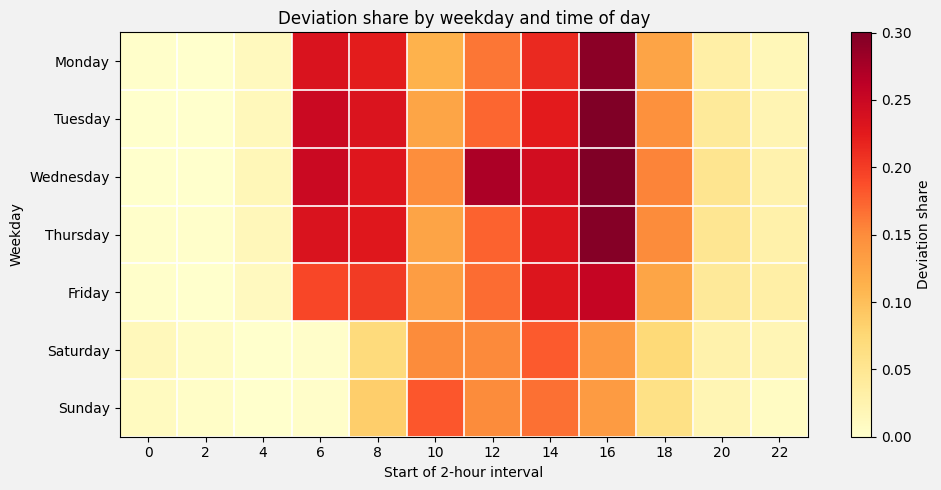

In [35]:
hour_weekday_summary = plot_deviation_share_heatmap(
    data=deviation_data,
    row_variable="weekday",
    column_variable="hour_bin",
    row_order=weekday_order,
    column_order=None,
    title="Deviation share by weekday and time of day",
    x_label="Start of 2-hour interval",
    y_label="Weekday"
)

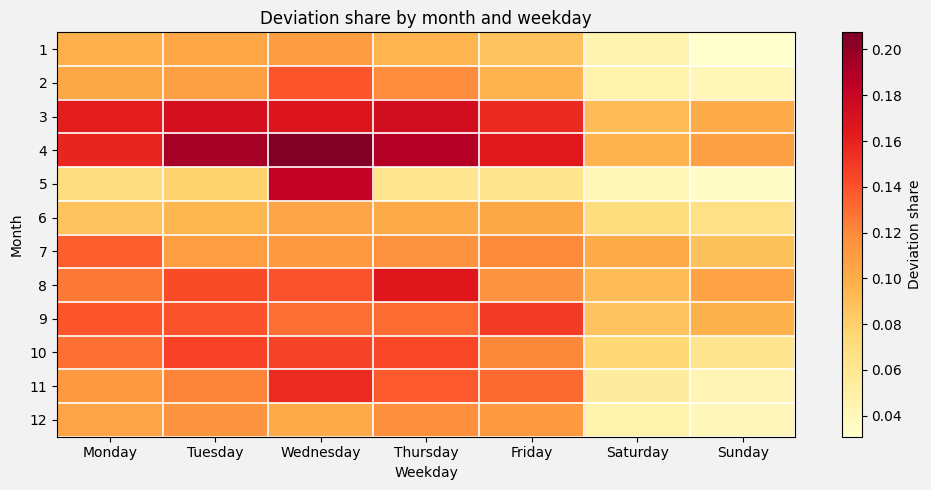

In [36]:
month_weekday_summary = plot_deviation_share_heatmap(
    data=deviation_data,
    row_variable="month",
    column_variable="weekday",
    row_order=None,
    column_order=weekday_order,
    title="Deviation share by month and weekday",
    x_label="Weekday",
    y_label="Month"
)

### Deviations and weather

In [37]:
precipitation_category_deviation_summary = summarize_deviations(
    deviation_data,
    "precipitation_category"
)

precipitation_order = [
    "dry",
    "light_precipitation",
    "moderate_precipitation",
    "heavy_precipitation",
    "snow"
]

precipitation_deviation_summary = (
    precipitation_category_deviation_summary
    .set_index("precipitation_category")
    .reindex(precipitation_order)
    .reset_index()
)

precipitation_deviation_summary

,precipitation_category,observations,deviations,deviation_share,baseline_deviation_share
0,dry,937578,104808,0.111786,0.110221
1,light_precipitation,181661,20465,0.112655,0.110221
2,moderate_precipitation,40432,3185,0.078774,0.110221
3,heavy_precipitation,4572,439,0.096019,0.110221
4,snow,13332,896,0.067207,0.110221


In [38]:
precipitation_category_directional_deviation_summary = summarize_directional_deviations(
    deviation_data,
    "precipitation_category"
)

precipitation_directional_deviation_summary = (
    precipitation_category_directional_deviation_summary
    .set_index("precipitation_category")
    .reindex(precipitation_order)
    .reset_index()
)

precipitation_directional_deviation_summary

,precipitation_category,observations,deviations,higher_deviations,lower_deviations,deviation_share,higher_deviation_share,lower_deviation_share,baseline_deviation_share,baseline_higher_deviation_share,baseline_lower_deviation_share
0,dry,937578,104808,66404,38404,0.111786,0.070825,0.040961,0.110221,0.06506,0.045161
1,light_precipitation,181661,20465,8921,11544,0.112655,0.049108,0.063547,0.110221,0.06506,0.045161
2,moderate_precipitation,40432,3185,888,2297,0.078774,0.021963,0.056811,0.110221,0.06506,0.045161
3,heavy_precipitation,4572,439,82,357,0.096019,0.017935,0.078084,0.110221,0.06506,0.045161
4,snow,13332,896,318,578,0.067207,0.023852,0.043354,0.110221,0.06506,0.045161


In [39]:
deviation_data["temperature_bin"] = pd.cut(
    deviation_data["temperature_mean"],
    bins=[-20,-15,-10, 0, 5, 10, 15, 20, 25, 35, 40, 45],
)

temperature_deviation_summary = summarize_deviations(
    deviation_data,
    "temperature_bin"
)

temperature_deviation_summary

,temperature_bin,observations,deviations,deviation_share,baseline_deviation_share
0,"(-10, 0]",36502,1222,0.033478,0.110221
1,"(0, 5]",142950,10927,0.076439,0.110221
2,"(5, 10]",282583,27917,0.098792,0.110221
3,"(10, 15]",335558,35973,0.107204,0.110221
4,"(15, 20]",234006,30578,0.130672,0.110221
5,"(20, 25]",109994,17334,0.157590,0.110221
6,"(25, 35]",35534,5768,0.162323,0.110221
7,"(35, 40]",448,74,0.165179,0.110221


In [40]:
temperature_direction_summary = summarize_directional_deviations(
    deviation_data,
    "temperature_bin"
)

temperature_direction_summary

,temperature_bin,observations,deviations,higher_deviations,lower_deviations,deviation_share,higher_deviation_share,lower_deviation_share,baseline_deviation_share,baseline_higher_deviation_share,baseline_lower_deviation_share
0,"(-10, 0]",36502,1222,590,632,0.033478,0.016163,0.017314,0.110221,0.06506,0.045161
1,"(0, 5]",142950,10927,6959,3968,0.076439,0.048681,0.027758,0.110221,0.06506,0.045161
2,"(5, 10]",282583,27917,18301,9616,0.098792,0.064763,0.034029,0.110221,0.06506,0.045161
3,"(10, 15]",335558,35973,21381,14592,0.107204,0.063718,0.043486,0.110221,0.06506,0.045161
4,"(15, 20]",234006,30578,16645,13933,0.130672,0.071131,0.059541,0.110221,0.06506,0.045161
5,"(20, 25]",109994,17334,9554,7780,0.157590,0.086859,0.070731,0.110221,0.06506,0.045161
6,"(25, 35]",35534,5768,3166,2602,0.162323,0.089098,0.073226,0.110221,0.06506,0.045161
7,"(35, 40]",448,74,17,57,0.165179,0.037946,0.127232,0.110221,0.06506,0.045161


In [41]:
temperature_long = temperature_direction_summary.melt(
    id_vars="temperature_bin",
    value_vars=[
        "higher_deviation_share",
        "lower_deviation_share"
    ],
    var_name="direction",
    value_name="share",
)

temperature_long["direction"] = temperature_long["direction"].map({
    "higher_deviation_share": "Higher than expected",
    "lower_deviation_share": "Lower than expected",
})

temperature_long["temperature_bin"] = (
    temperature_long["temperature_bin"].astype(str)
)

direction_colors = {
    "Higher than expected": "#b2182b",
    "Lower than expected": "#fdae61",
}

fig = plotly.line(
    temperature_long,
    x="temperature_bin",
    y="share",
    color="direction",
    color_discrete_map=direction_colors,
    markers=True,
    title="Deviation direction by temperature",
    labels={
        "temperature_bin": "Temperature bin",
        "share": "Share of observations",
        "direction": "Deviation direction",
    },
)

fig.update_traces(
    line=dict(width=3),
    marker=dict(size=8)
)

fig.update_layout(
    plot_bgcolor="#f2f2f2",
    paper_bgcolor="#f2f2f2",
    font=dict(color="#333333"),
    title=dict(x=0.02),
    legend_title_text="Deviation direction",
)

fig.update_yaxes(
    tickformat=".1%",
    gridcolor="white",
    zerolinecolor="white",
)

fig.update_xaxes(
    tickangle=45,
    showgrid=False,
)

fig.show()

**Precipitation**

Deviation shares are very similar during dry periods and light precipitation, both slightly above the overall baseline of 11.0%. Moderate precipitation, heavy precipitation, and snow show lower overall deviation shares. 

The direction of deviations differs by precipitation category. During dry periods, higher-than-expected deviations are more common than the overall higher-deviation baseline. Under precipitation, especially moderate and heavy precipitation, lower-than-expected deviations becomes more common. 

**Temperature**

Deviation shares increase with temperature. Cold temperature bins have clearly lower deviation shares than the overall baseline, while warmer bins, especially above 15°C, have higher deviation shares. The highest shares occur in the warmest bins.

The temperature pattern is visible in both directions, but warmer temperatures are especially associated with more deviations overall. Higher-than-expected deviations increase from colder to warmer bins, while lower-than-expected deviations also become more common above 15°C. The 35–40°C bin, however, shows a high lower-deviation share.

### Deviations and events

In [42]:
event_factors = [
    "is_strike",
    "is_outdoor_music",
    "is_indoor_music",
    "is_sport_event",
]

event_factor_labels = {
    "is_strike": "Transport strike",
    "is_outdoor_music": "Outdoor music event",
    "is_indoor_music": "Indoor music event",
    "is_sport_event": "Sport event",
}

In [43]:
def summarize_event_deviations(data, event_factors, event_factor_labels):

    summary_list = []

    for factor in event_factors:
        non_event_data = data[data[factor] == 0]
        event_data = data[data[factor] == 1]

        non_event_observations = non_event_data.shape[0]
        event_observations = event_data.shape[0]

        non_event_deviation_share = non_event_data["is_deviation"].mean()
        event_deviation_share = event_data["is_deviation"].mean()

        non_event_higher_share = (
            non_event_data["deviation_direction"] == "Higher than expected"
        ).mean()

        event_higher_share = (
            event_data["deviation_direction"] == "Higher than expected"
        ).mean()

        non_event_lower_share = (
            non_event_data["deviation_direction"] == "Lower than expected"
        ).mean()

        event_lower_share = (
            event_data["deviation_direction"] == "Lower than expected"
        ).mean()

        summary_list.append({
            "factor": factor,
            "factor_label": event_factor_labels[factor],

            "non_event_observations": non_event_observations,
            "event_observations": event_observations,

            "non_event_deviation_share": non_event_deviation_share,
            "event_deviation_share": event_deviation_share,
            "difference_in_deviation_share": (
                event_deviation_share - non_event_deviation_share
            ),

            "non_event_higher_share": non_event_higher_share,
            "event_higher_share": event_higher_share,
            "difference_in_higher_share": (
                event_higher_share - non_event_higher_share
            ),

            "non_event_lower_share": non_event_lower_share,
            "event_lower_share": event_lower_share,
            "difference_in_lower_share": (
                event_lower_share - non_event_lower_share
            ),
        })

    return pd.DataFrame(summary_list)

Here we don't use the overall baseline anymore, we compare deviation shares with event absent and present.

In [44]:
event_deviation_summary = summarize_event_deviations(
    deviation_data,
    event_factors,
    event_factor_labels
)

event_deviation_summary

,factor,factor_label,non_event_observations,event_observations,non_event_deviation_share,event_deviation_share,difference_in_deviation_share,non_event_higher_share,event_higher_share,difference_in_higher_share,non_event_lower_share,event_lower_share,difference_in_lower_share
0,is_strike,Transport strike,1129175,48400,0.109288,0.131983,0.022696,0.064091,0.087665,0.023574,0.045197,0.044318,-0.000879
1,is_outdoor_music,Outdoor music event,1175439,2136,0.110046,0.206461,0.096415,0.064994,0.101124,0.036129,0.045051,0.105337,0.060286
2,is_indoor_music,Indoor music event,1177287,288,0.110208,0.163194,0.052987,0.065037,0.159722,0.094685,0.045171,0.003472,-0.041699
3,is_sport_event,Sport event,1175971,1604,0.110200,0.125312,0.015112,0.065059,0.065461,0.000402,0.045141,0.059850,0.014710


In [45]:
event_share_plot_data = event_deviation_summary.melt(
    id_vars=["factor_label"],
    value_vars=[
        "non_event_deviation_share",
        "event_deviation_share",
    ],
    var_name="period",
    value_name="deviation_share",
)

event_share_plot_data["period"] = event_share_plot_data["period"].map({
    "non_event_deviation_share": "Non-event period",
    "event_deviation_share": "Event period",
})

period_colors = {
    "Non-event period": "#999999",
    "Event period": "#b2182b",
}

fig = plotly.bar(
    event_share_plot_data,
    x="factor_label",
    y="deviation_share",
    color="period",
    color_discrete_map=period_colors,
    barmode="group",
    title="Deviation share during event and non-event periods",
    labels={
        "factor_label": "Event factor",
        "deviation_share": "Share of observations classified as deviations",
        "period": "Period",
    },
)

fig.update_layout(
    plot_bgcolor="#f2f2f2",
    paper_bgcolor="#f2f2f2",
    font=dict(color="#333333", size=13),
    title=dict(x=0.02, font=dict(size=21)),
    legend_title_text="Period",
    yaxis_tickformat=".1%",
    bargap=0.25,
    bargroupgap=0.08,
)

fig.update_yaxes(
    gridcolor="white",
    zerolinecolor="white",
    title="Deviation share"
)

fig.update_xaxes(
    showgrid=False,
    title="Event factor"
)

fig.show()

In [46]:
event_direction_plot_data = event_deviation_summary.melt(
    id_vars=["factor_label"],
    value_vars=[
        "event_higher_share",
        "event_lower_share",
    ],
    var_name="deviation_direction",
    value_name="deviation_share",
)

event_direction_plot_data["deviation_direction"] = event_direction_plot_data[
    "deviation_direction"
].map({
    "event_higher_share": "Higher than expected",
    "event_lower_share": "Lower than expected",
})

direction_colors = {
    "Higher than expected": "#b2182b",
    "Lower than expected": "#fdae61",
}

fig = plotly.bar(
    event_direction_plot_data,
    x="factor_label",
    y="deviation_share",
    color="deviation_direction",
    color_discrete_map=direction_colors,
    barmode="group",
    title="Direction of deviations during event periods",
    labels={
        "factor_label": "Event factor",
        "deviation_share": "Share of observations",
        "deviation_direction": "Deviation direction",
    },
)

fig.update_layout(
    plot_bgcolor="#f2f2f2",
    paper_bgcolor="#f2f2f2",
    font=dict(color="#333333", size=13),
    title=dict(x=0.02, font=dict(size=21)),
    legend_title_text="Deviation direction",
    yaxis_tickformat=".1%",
    bargap=0.25,
    bargroupgap=0.08,
)

fig.update_yaxes(
    gridcolor="white",
    zerolinecolor="white",
    title="Share of event-period observations"
)

fig.update_xaxes(
    showgrid=False,
    title="Event factor"
)

fig.show()

Overall, event periods tend to have higher deviation shares than non-event periods, especially outdoor music events and indoor music events. The direction of the change differs by event type. Indoor music events are mainly associated with more higher-than-expected deviations, outdoor music events show increases in both directions. Transport strikes re mainly associated with more higher-than-expected deviations. Sport events show increases in both directions.

# Analyzing Deviations: Regression approach

Packages

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

Deviation model data

In [48]:
deviation_model_data = deviation_data.copy()

deviation_model_data["is_higher_deviation"] = (
    deviation_model_data["deviation_direction"] == "Higher than expected"
).astype(int)

deviation_model_data["is_lower_deviation"] = (
    deviation_model_data["deviation_direction"] == "Lower than expected"
).astype(int)

**Features**: we estimate associations of deviations with weather and events, adjusting for broad time patterns

In [49]:
numeric_features = [
    "temperature_mean",
]

categorical_features = [
    "precipitation_category",
    "hour_bin",
    "weekday",
    "month",
]

binary_features = [
    "is_strike",
    "is_outdoor_music",
    "is_indoor_music",
    "is_sport_event",
]

model_features = (
    numeric_features
    + categorical_features
    + binary_features
)

Pipeline function

In [50]:
def build_logistic_pipeline():
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric_features),
            ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
            ("binary", "passthrough", binary_features),
        ]
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=1000))
        ]
    )

    return pipeline

Function defining outcome

In [51]:
def fit_deviation_logistic_model(data, outcome_column):
    X = data[model_features].copy()
    y = data[outcome_column].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=123,
        stratify=y
    )

    pipeline = build_logistic_pipeline()
    pipeline.fit(X_train, y_train)

    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

    model_performance = pd.DataFrame({
        "outcome": [outcome_column],
        "positive_class_share": [y_test.mean()],
        "mean_predicted_probability": [y_pred_proba.mean()],
        "roc_auc": [roc_auc_score(y_test, y_pred_proba)],
        "average_precision": [average_precision_score(y_test, y_pred_proba)],
    })

    feature_names = (
        pipeline
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )

    coefficients = (
        pipeline
        .named_steps["model"]
        .coef_[0]
    )

    coefficient_table = pd.DataFrame({
        "outcome": outcome_column,
        "feature": feature_names,
        "coefficient": coefficients,
    })

    coefficient_table["odds_ratio"] = np.exp(
        coefficient_table["coefficient"]
    )

    coefficient_table = coefficient_table.sort_values(
        "odds_ratio",
        ascending=False
    )

    return pipeline, coefficient_table, model_performance

In [52]:
any_deviation_pipeline, any_deviation_coefficients, any_deviation_performance = fit_deviation_logistic_model(
    deviation_model_data,
    "is_deviation"
)

In [53]:
higher_deviation_pipeline, higher_deviation_coefficients, higher_deviation_performance = fit_deviation_logistic_model(
    deviation_model_data,
    "is_higher_deviation"
)

In [54]:
lower_deviation_pipeline, lower_deviation_coefficients, lower_deviation_performance = fit_deviation_logistic_model(
    deviation_model_data,
    "is_lower_deviation"
)

In [55]:
logistic_performance = pd.concat(
    [
        any_deviation_performance,
        higher_deviation_performance,
        lower_deviation_performance,
    ],
    ignore_index=True
)

logistic_performance

,outcome,positive_class_share,mean_predicted_probability,roc_auc,average_precision
0,is_deviation,0.110221,0.110089,0.786250,0.273118
1,is_higher_deviation,0.065060,0.065208,0.776215,0.179085
2,is_lower_deviation,0.045161,0.045294,0.803170,0.127062


Average precision is lower because deviations are relatively rare, especially lower deviations.

In [56]:
all_logistic_coefficients = pd.concat(
    [
        any_deviation_coefficients,
        higher_deviation_coefficients,
        lower_deviation_coefficients,
    ],
    ignore_index=True
)

In [57]:
external_factor_coefficients = all_logistic_coefficients[
    all_logistic_coefficients["feature"].str.contains(
        "temperature|precipitation|strike|outdoor|indoor|sport",
        case=False,
        regex=True
    )
].copy()

external_factor_coefficients.sort_values(
    ["outcome", "odds_ratio"],
)

,outcome,feature,coefficient,odds_ratio
31,is_deviation,categorical__precipitation_category_snow,-0.337988,0.713204
30,is_deviation,categorical__precipitation_category_moderate_p...,-0.326371,0.721537
28,is_deviation,categorical__precipitation_category_light_prec...,-0.178677,0.836376
26,is_deviation,categorical__precipitation_category_heavy_prec...,-0.045116,0.955886
22,is_deviation,binary__is_strike,0.050903,1.052221
15,is_deviation,numeric__temperature_mean,0.292713,1.340058
12,is_deviation,binary__is_sport_event,0.551642,1.736102
11,is_deviation,binary__is_indoor_music,0.581954,1.789532
9,is_deviation,binary__is_outdoor_music,0.792998,2.210012
71,is_higher_deviation,categorical__precipitation_category_heavy_prec...,-1.362726,0.255962


Confidence Intervals for Odds Ratios

In [58]:
def bootstrap_odds_ratios(
    data,
    outcome_column,
    n_bootstraps=100,
    random_state=123
):
    X = data[model_features].copy()
    y = data[outcome_column].copy()

    bootstrap_coefficients = []

    rng = np.random.default_rng(random_state)

    for i in range(n_bootstraps):
        sample_indices = rng.choice(
            data.index,
            size=len(data),
            replace=True
        )

        X_boot = X.loc[sample_indices]
        y_boot = y.loc[sample_indices]

        pipeline = build_logistic_pipeline()
        pipeline.fit(X_boot, y_boot)

        feature_names = (
            pipeline
            .named_steps["preprocessor"]
            .get_feature_names_out()
        )

        coefficients = (
            pipeline
            .named_steps["model"]
            .coef_[0]
        )

        temp = pd.DataFrame({
            "feature": feature_names,
            "coefficient": coefficients,
            "bootstrap": i,
        })

        bootstrap_coefficients.append(temp)

    bootstrap_coefficients = pd.concat(
        bootstrap_coefficients,
        ignore_index=True
    )

    coefficient_ci = (
        bootstrap_coefficients
        .groupby("feature")
        .agg(
            coefficient_mean=("coefficient", "mean"),
            coefficient_lower=("coefficient", lambda x: np.percentile(x, 2.5)),
            coefficient_upper=("coefficient", lambda x: np.percentile(x, 97.5)),
        )
        .reset_index()
    )

    coefficient_ci["odds_ratio"] = np.exp(
        coefficient_ci["coefficient_mean"]
    )

    coefficient_ci["odds_ratio_lower"] = np.exp(
        coefficient_ci["coefficient_lower"]
    )

    coefficient_ci["odds_ratio_upper"] = np.exp(
        coefficient_ci["coefficient_upper"]
    )

    coefficient_ci["outcome"] = outcome_column

    return coefficient_ci

In [59]:
any_deviation_odds_ci = bootstrap_odds_ratios(
    deviation_model_data,
    outcome_column="is_deviation",
    n_bootstraps=30
)

higher_deviation_odds_ci = bootstrap_odds_ratios(
    deviation_model_data,
    outcome_column="is_higher_deviation",
    n_bootstraps=30
)

lower_deviation_odds_ci = bootstrap_odds_ratios(
    deviation_model_data,
    outcome_column="is_lower_deviation",
    n_bootstraps=30
)

In [60]:
all_odds_ci = pd.concat(
    [
        any_deviation_odds_ci,
        higher_deviation_odds_ci,
        lower_deviation_odds_ci,
    ],
    ignore_index=True
)

In [61]:
external_factors_odds_ci = all_odds_ci[
    all_odds_ci["feature"].str.contains(
        "temperature|precipitation|strike|outdoor|indoor|sport",
        case=False,
        regex=True
    )
].copy()


external_factors_odds_ci

,feature,coefficient_mean,coefficient_lower,coefficient_upper,odds_ratio,odds_ratio_lower,odds_ratio_upper,outcome
0,binary__is_indoor_music,0.788656,0.562341,1.002477,2.200437,1.754776,2.725024,is_deviation
1,binary__is_outdoor_music,0.874775,0.739959,1.023325,2.398336,2.095849,2.782432,is_deviation
2,binary__is_sport_event,0.518620,0.293057,0.701705,1.679708,1.340519,2.017189,is_deviation
3,binary__is_strike,0.061559,0.028596,0.101050,1.063493,1.029009,1.106332,is_deviation
26,categorical__precipitation_category_heavy_prec...,-0.072293,-0.139017,-0.019101,0.930258,0.870213,0.981081,is_deviation
27,categorical__precipitation_category_light_prec...,-0.192615,-0.208457,-0.178824,0.824799,0.811836,0.836253,is_deviation
28,categorical__precipitation_category_moderate_p...,-0.334055,-0.366707,-0.293909,0.716015,0.693013,0.745344,is_deviation
29,categorical__precipitation_category_snow,-0.402281,-0.478524,-0.316608,0.668793,0.619697,0.728616,is_deviation
36,numeric__temperature_mean,0.298072,0.284887,0.313330,1.347259,1.329612,1.367972,is_deviation
37,binary__is_indoor_music,0.762724,0.525087,0.995253,2.144110,1.690606,2.705408,is_higher_deviation


The adjusted logistic regression results are broadly consistent with the descriptive summaries. Higher temperatures are associated with increased odds of any deviation and especially higher-than-expected deviations. Compared with dry periods, precipitation categories generally reduce the odds of higher-than-expected deviations but increase the odds of lower-than-expected deviations. Event indicators, especially outdoor and indoor music events, are associated with increased odds of deviations.

The bootstrap intervals suggest that the strongest associations are stable across resamples. Outdoor music events, indoor music events, sport events, and temperature show odds ratios above 1 for any deviation. For directional outcomes, precipitation is consistently associated with lower odds of higher-than-expected deviations and higher odds of lower-than-expected deviations. This supports the interpretation that weather conditions affect not only the probability of a deviation, but also its direction.

# Analyzing Deviations: Site Analysis

### Deviations by site

In [62]:
site_deviation_summary = (
    deviation_data
    .groupby(["site_id", "site_name", "municipality", "latitude", "longitude"])
    .agg(
        observations=("is_deviation", "size"),
        deviations=("is_deviation", "sum"),
        higher_deviations=(
            "deviation_direction",
            lambda x: (x == "Higher than expected").sum()
        ),
        lower_deviations=(
            "deviation_direction",
            lambda x: (x == "Lower than expected").sum()
        ),
    )
    .reset_index()
)

site_deviation_summary["deviation_share"] = (
    site_deviation_summary["deviations"] / site_deviation_summary["observations"]
)

site_deviation_summary["higher_deviation_share"] = (
    site_deviation_summary["higher_deviations"] / site_deviation_summary["observations"]
)

site_deviation_summary["lower_deviation_share"] = (
    site_deviation_summary["lower_deviations"] / site_deviation_summary["observations"]
)

site_deviation_summary

,site_id,site_name,municipality,latitude,longitude,observations,deviations,higher_deviations,lower_deviations,deviation_share,higher_deviation_share,lower_deviation_share
0,1,Machelen,Machelen,50.916183,4.456122,8758,146,75,71,0.016670,0.008564,0.008107
1,2,Brasschaat 2,Brasschaat,51.275120,4.471690,8758,2448,1295,1153,0.279516,0.147865,0.131651
2,3,Brasschaat 1,Brasschaat,51.275030,4.472220,8728,3992,1516,2476,0.457379,0.173694,0.283685
3,4,Balen 1,Balen,51.160230,5.190110,8758,701,570,131,0.080041,0.065083,0.014958
4,5,Balen 2,Balen,51.160180,5.190030,8758,767,488,279,0.087577,0.055720,0.031857
...,...,...,...,...,...,...,...,...,...,...,...,...
131,137,Hasselt-Kempische brug,Hasselt,50.941161,5.341758,8324,213,174,39,0.025589,0.020903,0.004685
132,138,Hasselt-Kempische brug,Hasselt,50.940532,5.342247,8758,440,255,185,0.050240,0.029116,0.021124
133,139,Houthalen-Helchteren,Houthalen-Helchteren,51.064427,5.381980,8758,194,194,0,0.022151,0.022151,0.000000
134,140,Hasselt ring,Hasselt,50.930004,5.343862,8758,102,76,26,0.011646,0.008678,0.002969


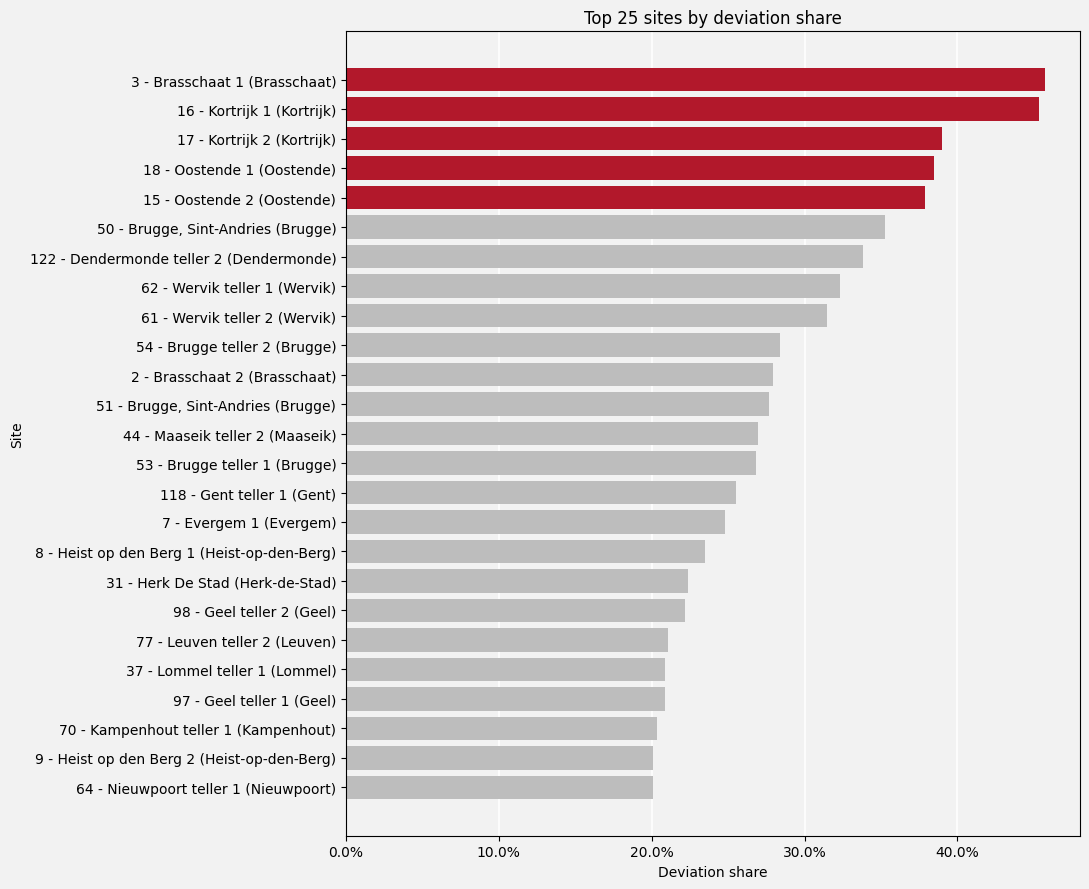

In [63]:
top_sites = (
    site_deviation_summary
    .sort_values("deviation_share", ascending=False)
    .head(25)
    .copy()
)

top_sites["site_label"] = (
    top_sites["site_id"].astype(str)
    + " - "
    + top_sites["site_name"]
    + " ("
    + top_sites["municipality"]
    + ")"
)

top_sites["rank"] = range(1, len(top_sites) + 1)

top_sites["bar_color"] = np.where(
    top_sites["rank"] <= 5,
    "#b2182b",   
    "#bdbdbd"    
)


top_sites = top_sites.sort_values("deviation_share", ascending=True)

fig, ax = plt.subplots(figsize=(11, 9))

fig.patch.set_facecolor("#f2f2f2")
ax.set_facecolor("#f2f2f2")

ax.barh(
    top_sites["site_label"],
    top_sites["deviation_share"],
    color=top_sites["bar_color"],
)

ax.set_xlabel("Deviation share")
ax.set_ylabel("Site")
ax.set_title("Top 25 sites by deviation share")

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="x", color="white", linewidth=1.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Deviation maps

In [64]:
def plot_deviation_map_plotly(data, share_column, count_column, title):
    fig = plotly.scatter_map(
        data,
        lat="latitude",
        lon="longitude",
        size=count_column,
        color=share_column,
        hover_name="site_name",
        hover_data={
            "site_id": True,
            "municipality": True,
            "observations": True,
            count_column: True,
            share_column: ":.2%",
            "latitude": False,
            "longitude": False,
        },
        color_continuous_scale="YlOrRd",
        size_max=25,
        zoom=7,
        height=700,
        title=title,
    )

    fig.update_layout(
        map_style="carto-positron",
        margin={"r": 0, "t": 50, "l": 0, "b": 0},
    )

    fig.show()

In the maps, marker colour represents the site-level deviation share, marker size represents the number of deviation observations. This allows sites with high relative deviation frequency and sites with many absolute deviations to be inspected together.

In [65]:
plot_deviation_map_plotly(
    data=site_deviation_summary,
    share_column="deviation_share",
    count_column="deviations",
    title="Deviation share by counting site"
)

In [66]:
plot_deviation_map_plotly(
    data=site_deviation_summary,
    share_column="higher_deviation_share",
    count_column="higher_deviations",
    title="Higher-than-expected deviation share by counting site"
)

In [67]:
plot_deviation_map_plotly(
    data=site_deviation_summary,
    share_column="lower_deviation_share",
    count_column="lower_deviations",
    title="Lower-than-expected deviation share by counting site"
)

The two maps show that high and low deviations do not behave in exactly the same way across sites. Lower-than-expected deviations seem to be concentrated in a few specific locations. In those places, the share of lower deviations is very high, which suggests that these sites repeatedly recorded much less cycling traffic than the model expected.

Higher-than-expected deviations look more spread out. They occur at more sites, but not always with such extreme site-level shares. This means that looking only at percentages could make some important high-count sites look less visible. 

## Characterising sites

### **Sites by deviation type**

Given that our deviation definition is already quite strict, we do not need a very high site-level threshold. If at least 10% of a site’s observations are classified as deviations, we treat that site as meaningfully deviation-prone. 

If one direction of deviation occurs at least 1.5 times as often as the other, we describe the site as mostly higher-than-expected or mostly lower-than-expected. If neither direction clearly dominates, we call it mixed.

In [127]:
site_characterisation = site_deviation_summary.copy()

site_characterisation["direction_profile"] = "Low deviation frequency"

high_deviation_frequency = site_characterisation["deviation_share"] >= 0.10

site_characterisation.loc[
    high_deviation_frequency &
    (
        site_characterisation["higher_deviation_share"]
        > 1.5 * site_characterisation["lower_deviation_share"]
    ),
    "direction_profile"
] = "Mostly higher counts than expected"

site_characterisation.loc[
    high_deviation_frequency &
    (
        site_characterisation["lower_deviation_share"]
        > 1.5 * site_characterisation["higher_deviation_share"]
    ),
    "direction_profile"
] = "Mostly lower counts than expected"

site_characterisation.loc[
    high_deviation_frequency &
    (
        site_characterisation["higher_deviation_share"]
        <= 1.5 * site_characterisation["lower_deviation_share"]
    ) &
    (
        site_characterisation["lower_deviation_share"]
        <= 1.5 * site_characterisation["higher_deviation_share"]
    ),
    "direction_profile"
] = "Mixed direction of deviations"

site_characterisation["direction_profile"].value_counts()

direction_profile
Low deviation frequency               78
Mostly higher counts than expected    27
Mixed direction of deviations         17
Mostly lower counts than expected     14
Name: count, dtype: int64

In [128]:
site_characterisation.head(10)

,site_id,site_name,municipality,latitude,longitude,observations,deviations,higher_deviations,lower_deviations,deviation_share,higher_deviation_share,lower_deviation_share,direction_profile
0,1,Machelen,Machelen,50.916183,4.456122,8758,146,75,71,0.016670,0.008564,0.008107,Low deviation frequency
1,2,Brasschaat 2,Brasschaat,51.275120,4.471690,8758,2448,1295,1153,0.279516,0.147865,0.131651,Mixed direction of deviations
2,3,Brasschaat 1,Brasschaat,51.275030,4.472220,8728,3992,1516,2476,0.457379,0.173694,0.283685,Mostly lower counts than expected
3,4,Balen 1,Balen,51.160230,5.190110,8758,701,570,131,0.080041,0.065083,0.014958,Low deviation frequency
4,5,Balen 2,Balen,51.160180,5.190030,8758,767,488,279,0.087577,0.055720,0.031857,Low deviation frequency
5,6,Evergem 2,Evergem,51.108940,3.702980,8086,1552,702,850,0.191937,0.086817,0.105120,Mixed direction of deviations
6,7,Evergem 1,Evergem,51.108900,3.703170,8758,2173,823,1350,0.248116,0.093971,0.154145,Mostly lower counts than expected
7,8,Heist op den Berg 1,Heist-op-den-Berg,51.067590,4.688230,8758,2057,860,1197,0.234871,0.098196,0.136675,Mixed direction of deviations
8,9,Heist op den Berg 2,Heist-op-den-Berg,51.069040,4.695240,8758,1758,770,988,0.200731,0.087920,0.112811,Mixed direction of deviations
9,10,Aalst 2,Aalst,50.935490,4.015710,8758,386,377,9,0.044074,0.043046,0.001028,Low deviation frequency


### **Sites by sensitivity of their deviations to external conditions**

In this section, we classify sites based on whether their deviations appear to be independent of external conditions or related to specific external conditions.

### External-condition indicators

In [ ]:
# Cultural events (outdoor or indoor music events)
deviation_data["is_cultural_event"] = (
    (deviation_data["is_outdoor_music"] == 1) |
    (deviation_data["is_indoor_music"] == 1)
).astype(int)


# Strong precipitation (moderate precipitation or heavy precipitation or snow)
deviation_data["meaningful_precipitation"] = (
    deviation_data["precipitation_category"].isin([
        "moderate_precipitation",
        "heavy_precipitation",
        "snow",
    ])
).astype(int)

# Extreme temperatures (below 5th percentile or above 95th percentile of temperature_mean)
cold_temperature_threshold = deviation_data["temperature_mean"].quantile(0.05)
warm_temperature_threshold = deviation_data["temperature_mean"].quantile(0.95)

deviation_data["cold_weather"] = (
    deviation_data["temperature_mean"] <= cold_temperature_threshold
).astype(int)

deviation_data["warm_weather"] = (
    deviation_data["temperature_mean"] >= warm_temperature_threshold
).astype(int)


### Normal external conditions

In [130]:
deviation_data["normal_external_conditions"] = (
    (deviation_data["is_strike"] == 0) &
    (deviation_data["is_cultural_event"] == 0) &
    (deviation_data["is_sport_event"] == 0) &
    (deviation_data["meaningful_precipitation"] == 0) &
    (deviation_data["cold_weather"] == 0) &
    (deviation_data["warm_weather"] == 0)
).astype(int)

In [150]:
external_condition_columns = [
    "is_strike",
    "is_cultural_event",
    "is_sport_event",
    "meaningful_precipitation",
    "cold_weather",
    "warm_weather",
    "normal_external_conditions",
]

for column in external_condition_columns:
    print("\n", column)
    print(deviation_data[column].value_counts())
    print(deviation_data[column].value_counts(normalize=True))


 is_strike
is_strike
0    1129175
1      48400
Name: count, dtype: int64
is_strike
0    0.958899
1    0.041101
Name: proportion, dtype: float64

 is_cultural_event
is_cultural_event
0    1175151
1       2424
Name: count, dtype: int64
is_cultural_event
0    0.997942
1    0.002058
Name: proportion, dtype: float64

 is_sport_event
is_sport_event
0    1175971
1       1604
Name: count, dtype: int64
is_sport_event
0    0.998638
1    0.001362
Name: proportion, dtype: float64

 meaningful_precipitation
meaningful_precipitation
0    1119239
1      58336
Name: count, dtype: int64
meaningful_precipitation
0    0.950461
1    0.049539
Name: proportion, dtype: float64

 cold_weather
cold_weather
0    1118215
1      59360
Name: count, dtype: int64
cold_weather
0    0.949591
1    0.050409
Name: proportion, dtype: float64

 warm_weather
warm_weather
0    1118029
1      59546
Name: count, dtype: int64
warm_weather
0    0.949433
1    0.050567
Name: proportion, dtype: float64

 normal_external_conditions

### Deviation share under normal conditions

For each site, we calculate the deviation share during normal external conditions. This becomes the baseline against which factor-specific deviation shares are compared.


In [132]:
normal_site_summary = (
    deviation_data[deviation_data["normal_external_conditions"] == 1]
    .groupby("site_id")
    .agg(
        normal_observations=("is_deviation", "size"),
        normal_deviations=("is_deviation", "sum"),
    )
    .reset_index()
)

normal_site_summary["normal_deviation_share"] = (
    normal_site_summary["normal_deviations"]
    / normal_site_summary["normal_observations"]
)

site_characterisation = site_characterisation.merge(
    normal_site_summary,
    on="site_id",
    how="left"
)

site_characterisation["normal_observations"] = (
    site_characterisation["normal_observations"]
    .fillna(0)
    .astype(int)
)

site_characterisation["normal_deviations"] = (
    site_characterisation["normal_deviations"]
    .fillna(0)
    .astype(int)
)

site_characterisation["normal_deviation_share"] = np.where(
    site_characterisation["normal_observations"] > 0,
    site_characterisation["normal_deviation_share"],
    np.nan
)

site_characterisation.head()

,site_id,site_name,municipality,latitude,longitude,observations,deviations,higher_deviations,lower_deviations,deviation_share,higher_deviation_share,lower_deviation_share,direction_profile,normal_observations,normal_deviations,normal_deviation_share
0,1,Machelen,Machelen,50.916183,4.456122,8758,146,75,71,0.016670,0.008564,0.008107,Low deviation frequency,7130,109,0.015288
1,2,Brasschaat 2,Brasschaat,51.275120,4.471690,8758,2448,1295,1153,0.279516,0.147865,0.131651,Mixed direction of deviations,7164,2015,0.281267
2,3,Brasschaat 1,Brasschaat,51.275030,4.472220,8728,3992,1516,2476,0.457379,0.173694,0.283685,Mostly lower counts than expected,7134,3248,0.455285
3,4,Balen 1,Balen,51.160230,5.190110,8758,701,570,131,0.080041,0.065083,0.014958,Low deviation frequency,7026,505,0.071876
4,5,Balen 2,Balen,51.160180,5.190030,8758,767,488,279,0.087577,0.055720,0.031857,Low deviation frequency,7026,524,0.074580


### Sensitivity to external conditions

A site is considered unstable if at least 10% of its observations are deviations.

Among unstable sites, sensitivity to an external factor is assigned when the deviation share under that factor is at least 5 percentage points higher than the site's normal-condition deviation share

In [133]:
UNSTABLE_THRESHOLD = 0.10
SENSITIVITY_THRESHOLD = 0.05

factor_columns = [
    "meaningful_precipitation",
    "cold_weather",
    "warm_weather",
    "is_strike",
    "is_cultural_event",
    "is_sport_event",
]

factor_labels = {
    "meaningful_precipitation": "Precipitation",
    "cold_weather": "Cold weather",
    "warm_weather": "Warm weather",
    "is_strike": "Transport strike",
    "is_cultural_event": "Cultural event",
    "is_sport_event": "Sport event",
}

In [134]:
factor_summary_list = []

for factor_column in factor_columns:
    temp = (
        deviation_data[deviation_data[factor_column] == 1]
        .groupby("site_id")
        .agg(
            factor_observations=("is_deviation", "size"),
            factor_deviations=("is_deviation", "sum"),
        )
        .reset_index()
    )

    temp["factor"] = factor_column
    temp["factor_label"] = factor_labels[factor_column]

    temp["factor_deviation_share"] = (
        temp["factor_deviations"] / temp["factor_observations"]
    )

    factor_summary_list.append(temp)

site_factor_sensitivity = pd.concat(
    factor_summary_list,
    ignore_index=True
)

site_factor_sensitivity.head(20)

,site_id,factor_observations,factor_deviations,factor,factor_label,factor_deviation_share
0,1,428,22,meaningful_precipitation,Precipitation,0.051402
1,2,414,91,meaningful_precipitation,Precipitation,0.219807
2,3,414,158,meaningful_precipitation,Precipitation,0.381643
3,4,448,13,meaningful_precipitation,Precipitation,0.029018
4,5,448,17,meaningful_precipitation,Precipitation,0.037946
5,6,408,53,meaningful_precipitation,Precipitation,0.129902
6,7,408,82,meaningful_precipitation,Precipitation,0.200980
7,8,414,59,meaningful_precipitation,Precipitation,0.142512
8,9,414,68,meaningful_precipitation,Precipitation,0.164251
9,10,440,7,meaningful_precipitation,Precipitation,0.015909


We add each site's normal-condition deviation share to the factor table. We calculate how much higher the factor-specific deviation share is compared with that site's own normal-condition baseline.


In [135]:
site_factor_sensitivity = site_factor_sensitivity.merge(
    site_characterisation[
        [
            "site_id",
            "site_name",
            "municipality",
            "deviation_share",
            "normal_deviation_share",
        ]
    ],
    on="site_id",
    how="left"
)

site_factor_sensitivity["lift_from_normal"] = (
    site_factor_sensitivity["factor_deviation_share"]
    - site_factor_sensitivity["normal_deviation_share"]
)

site_factor_sensitivity["is_sensitive"] = (
    (site_factor_sensitivity["deviation_share"] >= UNSTABLE_THRESHOLD) &
    (site_factor_sensitivity["lift_from_normal"] >= SENSITIVITY_THRESHOLD)
).astype(int)

site_factor_sensitivity.head(20)

,site_id,factor_observations,factor_deviations,factor,factor_label,factor_deviation_share,site_name,municipality,deviation_share,normal_deviation_share,lift_from_normal,is_sensitive
0,1,428,22,meaningful_precipitation,Precipitation,0.051402,Machelen,Machelen,0.016670,0.015288,0.036114,0
1,2,414,91,meaningful_precipitation,Precipitation,0.219807,Brasschaat 2,Brasschaat,0.279516,0.281267,-0.061461,0
2,3,414,158,meaningful_precipitation,Precipitation,0.381643,Brasschaat 1,Brasschaat,0.457379,0.455285,-0.073642,0
3,4,448,13,meaningful_precipitation,Precipitation,0.029018,Balen 1,Balen,0.080041,0.071876,-0.042858,0
4,5,448,17,meaningful_precipitation,Precipitation,0.037946,Balen 2,Balen,0.087577,0.074580,-0.036634,0
5,6,408,53,meaningful_precipitation,Precipitation,0.129902,Evergem 2,Evergem,0.191937,0.193237,-0.063335,0
6,7,408,82,meaningful_precipitation,Precipitation,0.200980,Evergem 1,Evergem,0.248116,0.239824,-0.038844,0
7,8,414,59,meaningful_precipitation,Precipitation,0.142512,Heist op den Berg 1,Heist-op-den-Berg,0.234871,0.232460,-0.089948,0
8,9,414,68,meaningful_precipitation,Precipitation,0.164251,Heist op den Berg 2,Heist-op-den-Berg,0.200731,0.196252,-0.032001,0
9,10,440,7,meaningful_precipitation,Precipitation,0.015909,Aalst 2,Aalst,0.044074,0.047188,-0.031279,0


The long table tells us which site is sensitive to which factor. Here we collapse it back to site level:
- number_of_sensitivities: how many external factors the site is sensitive to
- sensitive_factors: list of those factors
- main_sensitivity_factor: factor with the largest lift from normal

In [136]:
sensitive_factors_only = site_factor_sensitivity[
    site_factor_sensitivity["is_sensitive"] == 1
].copy()

number_of_sensitivities = (
    sensitive_factors_only
    .groupby("site_id")
    .size()
    .reset_index(name="number_of_sensitivities")
)

sensitive_factor_list = (
    sensitive_factors_only
    .sort_values(["site_id", "lift_from_normal"], ascending=[True, False])
    .groupby("site_id")["factor_label"]
    .apply(lambda x: ", ".join(x))
    .reset_index(name="sensitive_factors")
)

main_sensitivity_factor = (
    sensitive_factors_only
    .sort_values(["site_id", "lift_from_normal"], ascending=[True, False])
    .groupby("site_id")
    .first()
    .reset_index()[["site_id", "factor_label", "lift_from_normal"]]
    .rename(columns={
        "factor_label": "main_sensitivity_factor",
        "lift_from_normal": "main_sensitivity_lift",
    })
)

site_sensitivity_summary = (
    number_of_sensitivities
    .merge(sensitive_factor_list, on="site_id", how="left")
    .merge(main_sensitivity_factor, on="site_id", how="left")
)

site_sensitivity_summary.head()

,site_id,number_of_sensitivities,sensitive_factors,main_sensitivity_factor,main_sensitivity_lift
0,2,1,Warm weather,Warm weather,0.137143
1,3,2,"Warm weather, Transport strike",Warm weather,0.172331
2,6,1,Warm weather,Warm weather,0.129491
3,7,1,Warm weather,Warm weather,0.346540
4,8,1,Warm weather,Warm weather,0.248672


In [137]:
site_characterisation = site_characterisation.merge(
    site_sensitivity_summary,
    on="site_id",
    how="left"
)

site_characterisation["number_of_sensitivities"] = (
    site_characterisation["number_of_sensitivities"]
    .fillna(0)
    .astype(int)
)

site_characterisation["sensitive_factors"] = (
    site_characterisation["sensitive_factors"]
    .fillna("No sensitivities identified")
)

site_characterisation["main_sensitivity_factor"] = (
    site_characterisation["main_sensitivity_factor"]
    .fillna("No main sensitivity factor")
)

site_characterisation["main_sensitivity_lift"] = (
    site_characterisation["main_sensitivity_lift"]
    .fillna(0)
)

Here we assign final site sensitivity category

The final site category separates:
- Stable sites: low overall deviation frequency
- Unstable sites independent of factors: high deviation frequency, but no measured external factor clearly raises deviations above the normal baseline
- Single-factor-sensitive sites: high deviation frequency and sensitivity to one measured external factor
- Multiple-factor-sensitive sites: high deviation frequency and sensitivity to two or more measured external factors


In [138]:
site_characterisation["site_category"] = "Stable"

site_characterisation.loc[
    (site_characterisation["deviation_share"] >= UNSTABLE_THRESHOLD) &
    (site_characterisation["number_of_sensitivities"] == 0),
    "site_category"
] = "Unstable independent of factors"

site_characterisation.loc[
    (site_characterisation["deviation_share"] >= UNSTABLE_THRESHOLD) &
    (site_characterisation["number_of_sensitivities"] == 1),
    "site_category"
] = "Single-factor-sensitive"

site_characterisation.loc[
    (site_characterisation["deviation_share"] >= UNSTABLE_THRESHOLD) &
    (site_characterisation["number_of_sensitivities"] >= 2),
    "site_category"
] = "Multiple-factor-sensitive"

site_characterisation["site_category"].value_counts()

site_category
Stable                             78
Single-factor-sensitive            39
Multiple-factor-sensitive          13
Unstable independent of factors     6
Name: count, dtype: int64

In [139]:
site_characterisation["main_sensitivity_factor"].value_counts()

main_sensitivity_factor
No main sensitivity factor    84
Warm weather                  39
Transport strike              11
Cultural event                 1
Sport event                    1
Name: count, dtype: int64

In [140]:
site_category_summary = (
    site_characterisation
    .groupby("site_category")
    .agg(
        sites=("site_id", "size"),
        mean_deviation_share=("deviation_share", "mean"),
        median_deviation_share=("deviation_share", "median"),
        mean_normal_deviation_share=("normal_deviation_share", "mean"),
        median_normal_deviation_share=("normal_deviation_share", "median"),
    )
    .reset_index()
)

site_category_summary

,site_category,sites,mean_deviation_share,median_deviation_share,mean_normal_deviation_share,median_normal_deviation_share
0,Multiple-factor-sensitive,13,0.290642,0.284197,0.291453,0.284539
1,Single-factor-sensitive,39,0.181445,0.176410,0.181280,0.161485
2,Stable,78,0.041400,0.035453,0.042167,0.037122
3,Unstable independent of factors,6,0.137208,0.134220,0.140783,0.135193


### Maps for site categorization

In [141]:
site_map = site_characterisation.copy()

site_map["site_label"] = (
    site_map["site_id"].astype(str)
    + " - "
    + site_map["site_name"]
    + " ("
    + site_map["municipality"]
    + ")"
)

site_map["deviation_share_for_size"] = (
    site_map["deviation_share"] * 100
)

site_map.head()

,site_id,site_name,municipality,latitude,longitude,observations,deviations,higher_deviations,lower_deviations,deviation_share,...,normal_observations,normal_deviations,normal_deviation_share,number_of_sensitivities,sensitive_factors,main_sensitivity_factor,main_sensitivity_lift,site_category,site_label,deviation_share_for_size
0,1,Machelen,Machelen,50.916183,4.456122,8758,146,75,71,0.016670,...,7130,109,0.015288,0,No sensitivities identified,No main sensitivity factor,0.000000,Stable,1 - Machelen (Machelen),1.667047
1,2,Brasschaat 2,Brasschaat,51.275120,4.471690,8758,2448,1295,1153,0.279516,...,7164,2015,0.281267,1,Warm weather,Warm weather,0.137143,Single-factor-sensitive,2 - Brasschaat 2 (Brasschaat),27.951587
2,3,Brasschaat 1,Brasschaat,51.275030,4.472220,8728,3992,1516,2476,0.457379,...,7134,3248,0.455285,2,"Warm weather, Transport strike",Warm weather,0.172331,Multiple-factor-sensitive,3 - Brasschaat 1 (Brasschaat),45.737855
3,4,Balen 1,Balen,51.160230,5.190110,8758,701,570,131,0.080041,...,7026,505,0.071876,0,No sensitivities identified,No main sensitivity factor,0.000000,Stable,4 - Balen 1 (Balen),8.004111
4,5,Balen 2,Balen,51.160180,5.190030,8758,767,488,279,0.087577,...,7026,524,0.074580,0,No sensitivities identified,No main sensitivity factor,0.000000,Stable,5 - Balen 2 (Balen),8.757707


### Map 1: Direction profile of deviations by site

In [142]:
direction_colors = {
    "Low deviation frequency": "#9e9e9e",
    "Mostly higher counts than expected": "#b2182b",
    "Mostly lower counts than expected": "#fdae61",
    "Mixed direction of deviations": "#7b3294",
}


fig = plotly.scatter_map(
    site_map,
    lat="latitude",
    lon="longitude",
    color="direction_profile",
    size="deviation_share_for_size",
    color_discrete_map=direction_colors,
    size_max=24,
    zoom=7,
    height=700,
    hover_name="site_label",
    hover_data={
        "site_id": True,
        "municipality": True,
        "deviation_share": ":.1%",
        "higher_deviation_share": ":.1%",
        "lower_deviation_share": ":.1%",
        "direction_profile": True,
        "deviation_share_for_size": False,
        "latitude": False,
        "longitude": False,
    },
    title="Direction profile of deviations by counting site",
)

fig.update_layout(
    map_style="carto-positron",
    paper_bgcolor="#f2f2f2",
    plot_bgcolor="#f2f2f2",
    font=dict(color="#333333"),
    title=dict(x=0.02),
    legend_title_text="Direction profile",
    margin={"r": 0, "t": 55, "l": 0, "b": 0},
)

fig.show()



### Summary table: sites by direction of deviations category

In [143]:
direction_profile_summary = (
    site_map
    .groupby("direction_profile")
    .agg(
        sites=("site_id", "size"),
        mean_deviation_share=("deviation_share", "mean"),
        median_deviation_share=("deviation_share", "median"),
    )
    .reset_index()
)

direction_profile_summary

,direction_profile,sites,mean_deviation_share,median_deviation_share
0,Low deviation frequency,78,0.041400,0.035453
1,Mixed direction of deviations,17,0.216313,0.200731
2,Mostly higher counts than expected,27,0.139359,0.131423
3,Mostly lower counts than expected,14,0.302709,0.299441


### Map 2: Sensitivity map

In [144]:
site_map["sensitivity_map_group"] = site_map["site_category"]

site_map.loc[
    site_map["site_category"] == "Single-factor-sensitive",
    "sensitivity_map_group"
] = site_map["main_sensitivity_factor"]

site_map.loc[
    site_map["site_category"] == "Multiple-factor-sensitive",
    "sensitivity_map_group"
] = "Multiple factors"

In [145]:
sensitivity_colors = {
    "Stable": "#9e9e9e",
    "Unstable independent of factors": "#b2182b",
    "Warm weather": "#ef8a62",
    "Cold weather": "#67a9cf",
    "Precipitation": "#9ab5d0",
    "Transport strike":"#fdae61",
    "Cultural event": "#2166ac",
    "Sport event": "#d36c95",
    "Multiple factors": "#6a3d9a",
}

In [146]:
sensitivity_order = [
    "Stable",
    "Unstable independent of factors",
    "Precipitation",
    "Cold weather",
    "Warm weather",
    "Transport strike",
    "Cultural event",
    "Sport event",
    "Multiple factors",
]

In [147]:
fig = plotly.scatter_map(
    site_map,
    lat="latitude",
    lon="longitude",
    color="sensitivity_map_group",
    size="deviation_share_for_size",
    color_discrete_map=sensitivity_colors,
    category_orders={
        "sensitivity_map_group": sensitivity_order
    },
    size_max=24,
    zoom=7,
    height=700,
    hover_name="site_label",
    hover_data={
        "site_id": True,
        "municipality": True,
        "deviation_share": ":.1%",
        "normal_deviation_share": ":.1%",
        "site_category": True,
        "main_sensitivity_factor": True,
        "sensitive_factors": True,
        "direction_profile": True,
        "deviation_share_for_size": False,
        "latitude": False,
        "longitude": False,
    },
    title="Site sensitivity to external factors",
)

fig.update_layout(
    map_style="carto-positron",
    paper_bgcolor="#f2f2f2",
    plot_bgcolor="#f2f2f2",
    font=dict(color="#333333"),
    title=dict(x=0.02),
    legend_title_text="Sensitivity type",
    margin={"r": 0, "t": 55, "l": 0, "b": 0},
)

fig.show()

### Summary table: site by sensitivity to factors

In [152]:
sensitivity_summary = (
    site_map
    .groupby("sensitivity_map_group")
    .agg(
        sites=("site_id", "size"),
        mean_deviation_share=("deviation_share", "mean"),
        median_deviation_share=("deviation_share", "median"),
    )
    .reindex(sensitivity_order)
    .dropna()
    .reset_index()
)

sensitivity_summary

,sensitivity_map_group,sites,mean_deviation_share,median_deviation_share
0,Stable,78.0,0.041400,0.035453
1,Unstable independent of factors,6.0,0.137208,0.134220
2,Warm weather,30.0,0.188264,0.178863
3,Transport strike,9.0,0.158713,0.139301
4,Multiple factors,13.0,0.290642,0.284197


In [149]:
sensitive_sites_summary = (
    site_map[
        site_map["site_category"].isin([
            "Single-factor-sensitive",
            "Multiple-factor-sensitive",
        ])
    ][
        [
            "site_id",
            "site_name",
            "municipality",
            "deviation_share",
            "normal_deviation_share",
            "site_category",
            "main_sensitivity_factor",
            "sensitive_factors",
            "direction_profile",
        ]
    ]
    .sort_values("site_id")
)

sensitive_sites_summary

,site_id,site_name,municipality,deviation_share,normal_deviation_share,site_category,main_sensitivity_factor,sensitive_factors,direction_profile
1,2,Brasschaat 2,Brasschaat,0.279516,0.281267,Single-factor-sensitive,Warm weather,Warm weather,Mixed direction of deviations
2,3,Brasschaat 1,Brasschaat,0.457379,0.455285,Multiple-factor-sensitive,Warm weather,"Warm weather, Transport strike",Mostly lower counts than expected
5,6,Evergem 2,Evergem,0.191937,0.193237,Single-factor-sensitive,Warm weather,Warm weather,Mixed direction of deviations
6,7,Evergem 1,Evergem,0.248116,0.239824,Single-factor-sensitive,Warm weather,Warm weather,Mostly lower counts than expected
7,8,Heist op den Berg 1,Heist-op-den-Berg,0.234871,0.232460,Single-factor-sensitive,Warm weather,Warm weather,Mixed direction of deviations
8,9,Heist op den Berg 2,Heist-op-den-Berg,0.200731,0.196252,Single-factor-sensitive,Warm weather,Warm weather,Mixed direction of deviations
10,11,Aalst 3,Aalst,0.131423,0.130568,Single-factor-sensitive,Warm weather,Warm weather,Mostly higher counts than expected
12,13,Gent,Gent,0.139301,0.147382,Single-factor-sensitive,Transport strike,Transport strike,Mostly higher counts than expected
14,15,Oostende 2,Oostende,0.378739,0.380265,Multiple-factor-sensitive,Warm weather,"Warm weather, Cultural event",Mixed direction of deviations
15,16,Kortrijk 1,Kortrijk,0.453300,0.456312,Multiple-factor-sensitive,Warm weather,"Warm weather, Transport strike",Mostly lower counts than expected
